In [2]:
import pandas as pd
pd.read_csv("results_scored.csv")

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Scored,Letter,Score
0,struggle,BERT,4,31.49,Psalter,142,"Hear my prayer, O Lord; give ear unto my suppl...",False,A,1
1,struggle,SBERT,4,96.08,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,False,B,0
2,creation,TF-IDF + GloVe,2,13.98,Bible,122,1An ode of ascents Ilift my eyes to You Whodwe...,False,A,2
3,creation,BERT,2,40.51,Psalter,42,"Judge me, God, and give judgment in my cause a...",False,B,1
4,creation,SBERT,2,96.40,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,False,C,3
...,...,...,...,...,...,...,...,...,...,...
10778,Have Mercy on me,TF-IDF,3,36.23,Psalter,37,"O Lord, rebuke me not in Thy wrath, neither ch...",True,D,0
10779,Because of the distress of ther beggars and th...,TF-IDF + GloVe,2,13.98,Bible,122,1An ode of ascents Ilift my eyes to You Whodwe...,True,A,2
10780,Because of the distress of ther beggars and th...,BERT,2,84.14,Bible,134,Alleluia Praise the name of the Lord O you ser...,True,B,1
10781,Because of the distress of ther beggars and th...,SBERT,2,97.29,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,True,C,0


# Evaluation

In [3]:
import pandas as pd
scores = pd.read_csv("results_scored.csv")

# before giving the results in a random Order
pd.pivot_table(
    data=scores,
    values='Query',
    index=['Method'],
    columns='Score',
    aggfunc='count',
    fill_value=0
)

Score,0,1,2,3
Method,,,,
BERT,771,978,649,596
SBERT,832,748,702,468
TF-IDF,1014,490,736,253
TF-IDF + GloVe,408,746,533,859


In [4]:
from scipy.stats import chi2_contingency

#scores = scores.tail(20)

table = pd.crosstab(
    scores["Letter"],
    scores["Score"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 581.5056195531554
p-value: 1.9480043706271336e-119


$$ P_{value} =  9.81 × 10⁻²⁷$$
which is extremely small.
That means the score distributions are very unlikely to be the same across methods by random chance alone.

Previous stats: 
* Chi-square: 176.106
* p-value: 3.29e-33

### Cramer's V

Cramer's V is a measure of the strength of association between two categorical variables. Unlike a p-value, which tells you whether an effect is likely real, Cramer's V tells you how large the effect is.

### Guidelines for Interpreting Cramer's V

| Cramer's V | Interpretation |
|------------|---------------|
| < 0.10 | Negligible effect |
| 0.10 – 0.29 | Small effect |
| 0.30 – 0.49 | Medium effect |
| ≥ 0.50 | Large effect |

**Note:** Cramer's V ranges from 0 to 1, where 0 indicates no association and 1 indicates a perfect association between categorical variables.

In [5]:
from scipy.stats import chi2_contingency
import numpy as np

table = pd.crosstab(
    scores["Letter"],
    scores["Score"]
)

chi2, p, _, _ = chi2_contingency(table)

n = table.sum().sum()
r, k = table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(r-1, k-1))
)

print("Cramer's V:", cramers_v)

Cramer's V: 0.1340746055841125


### Why Cramer's V Was Preferred Over the p-value

- The p-value only indicates whether a statistically significant difference exists; it does not measure the magnitude of that difference.

- The p-value is highly sensitive to sample size. With a sufficiently large number of LLM evaluations, even trivial differences between retrieval methods may produce very small p-values.

- A significant p-value does not imply that the observed differences are practically meaningful for retrieval performance.

- Cramer's V provides a standardized measure of effect size, quantifying the strength of the association between retrieval method and LLM-assigned relevance scores.

- Unlike the p-value, Cramer's V allows the practical significance of differences between retrieval methods to be assessed and compared across experiments.

- Because the objective of this study is to evaluate the impact of retrieval methods on relevance scoring, effect size measurements such as Cramer's V are more informative than significance testing alone.

In [7]:
comparisons = pd.read_csv("method_comparisons.csv")

In [8]:
comparisons[['Query', 'Rank']].drop_duplicates().shape[0]

417

# Looking at different frequencies

In [9]:
pd.crosstab(comparisons["Method_A"], comparisons["Method_A_letter"])

Method_A_letter,A,B,X,Y
Method_A,,,,
BERT,1007,1002,990,946
SBERT,926,907,949,863
TF-IDF,965,898,904,899
TF-IDF + GloVe,864,891,881,838


In [10]:
comparisons = comparisons.loc[:, ~comparisons.columns.duplicated()]

In [11]:
method_letter_counts = pd.crosstab(
    comparisons["Method_A"],
    comparisons["Method_A_letter"],
)

method_letter_pct = (
    method_letter_counts.div(method_letter_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

summary_A = pd.concat(
    [method_letter_counts, method_letter_pct],
    axis=1,
    keys=["count", "percent"],
)


In [12]:


method_B_letter_counts = pd.crosstab(
    comparisons["Method_B"],
    comparisons["Method_B_letter"],
)

method_B_letter_pct = (
    method_B_letter_counts.div(method_B_letter_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

summary_B = pd.concat(
    [method_B_letter_counts, method_B_letter_pct],
    axis=1,
    keys=["count", "percent"],
)

In [13]:
print("Summary of Method A")
display(summary_A)

print("Summary of Method B")
display(summary_B)

Summary of Method A


count                 percent                     
Method_A_letter     A     B    X    Y       A      B      X      Y
Method_A                                                          
BERT             1007  1002  990  946   25.53  25.40  25.10  23.98
SBERT             926   907  949  863   25.40  24.88  26.04  23.68
TF-IDF            965   898  904  899   26.32  24.50  24.66  24.52
TF-IDF + GloVe    864   891  881  838   24.87  25.65  25.36  24.12

Summary of Method B


count                percent                     
Method_B_letter     A    B    X    Y       A      B      X      Y
Method_B                                                         
BERT              963  975  910  951   25.35  25.66  23.95  25.03
SBERT             932  923  896  904   25.50  25.25  24.51  24.73
TF-IDF            836  925  848  887   23.91  26.46  24.26  25.37
TF-IDF + GloVe    967  939  892  982   25.58  24.84  23.60  25.98

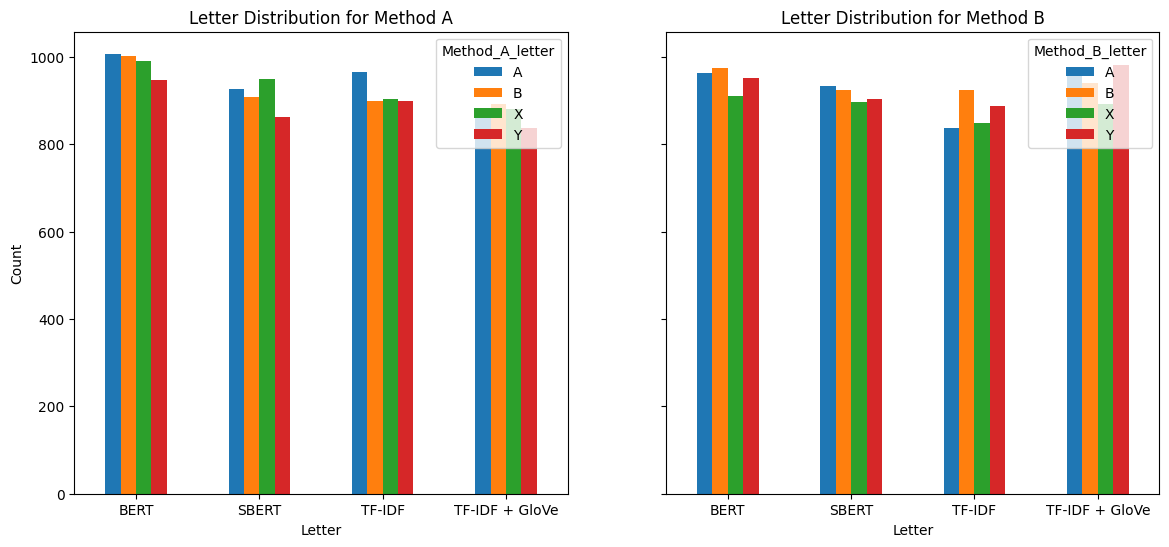

In [14]:
import matplotlib.pyplot as plt
# Extract count data
counts_A = summary_A['count']
counts_B = summary_B['count']

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Method A
counts_A.plot(kind='bar', ax=axes[0])
axes[0].set_title("Letter Distribution for Method A")
axes[0].set_xlabel("Letter")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

# Method B
counts_B.plot(kind='bar', ax=axes[1])
axes[1].set_title("Letter Distribution for Method B")
axes[1].set_xlabel("Letter")
axes[1].tick_params(axis='x', rotation=0)

plt.show()

## Observations
* The label distribution appears to be relatively balanced across methods.
* This means that there is no bias in certain letters and Methods. Meaning that the label does not directly indicate a specific method

In [15]:
comparisons.head()

,Query,Rank,Method_A,Method_A_letter,Method_B,Method_B_letter,Winner_Method
0,struggle,4,BERT,B,SBERT,A,BERT
1,creation,2,BERT,Y,TF-IDF + GloVe,X,TF-IDF + GloVe
2,creation,2,SBERT,B,TF-IDF + GloVe,A,SBERT
3,creation,2,TF-IDF,Y,TF-IDF + GloVe,X,TF-IDF + GloVe
4,creation,2,SBERT,X,BERT,Y,SBERT


In [16]:
comparisons.iloc[1]


Query                    creation
Rank                            2
Method_A                     BERT
Method_A_letter                 Y
Method_B           TF-IDF + GloVe
Method_B_letter                 X
Winner_Method      TF-IDF + GloVe
Name: 1, dtype: object

In [23]:

def indicate_winner(target):
    winner = target.iloc[6]

    if winner == target.iloc[2]:
        return ("A", "first")
    else:
        return ("B", "second")

comparisons[["winner", "winner_pos"]] = pd.DataFrame(
    comparisons.apply(indicate_winner, axis=1).tolist(),
    index=comparisons.index
)

In [24]:
comparisons.head()

,Query,Rank,Method_A,Method_A_letter,Method_B,Method_B_letter,Winner_Method,winner,_pair,winner_pos
0,struggle,4,BERT,B,SBERT,A,BERT,A,"(BERT, SBERT)",first
1,creation,2,BERT,Y,TF-IDF + GloVe,X,TF-IDF + GloVe,B,"(BERT, TF-IDF + GloVe)",second
2,creation,2,SBERT,B,TF-IDF + GloVe,A,SBERT,A,"(SBERT, TF-IDF + GloVe)",first
3,creation,2,TF-IDF,Y,TF-IDF + GloVe,X,TF-IDF + GloVe,B,"(TF-IDF, TF-IDF + GloVe)",second
4,creation,2,SBERT,X,BERT,Y,SBERT,A,"(BERT, SBERT)",first


In [18]:
comparisons['winner'].value_counts(normalize=True) * 100

winner
A    58.363883
B    41.636117
Name: proportion, dtype: float64

* Response **A** was selected as the winner in **58.4%** of comparisons, while response **B** was selected in **41.6%** of comparisons.
* If no position bias were present, the expected distribution would be approximately **50% for each position**.
* The observed difference suggests that responses appearing in the **first position may have been favored** by the evaluator.
* The gap of approximately **16.7 percentage points** indicates a moderate imbalance between the two positions.
* This result should be considered when interpreting the evaluation findings, as presentation order may have influenced some judgments.


In [19]:
from scipy.stats import chisquare

obs = comparisons['winner'].value_counts().sort_index()

chi2, p = chisquare(obs)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.6f}")

Chi-square: 412.172
p-value: 0.000000


In [20]:
import numpy as np

n = obs.sum()
chi2, p = chisquare(obs)

cramers_v = np.sqrt(chi2 / n)

print(f"Cramer's V: {cramers_v:.3f}")

Cramer's V: 0.167


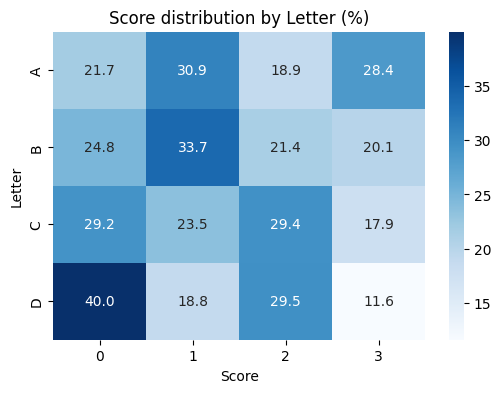

  method_a        method_b   p_value  cramers_v
5   TF-IDF  TF-IDF + GloVe  0.410119   0.020092
3    SBERT          TF-IDF  0.454471   0.018921
1     BERT          TF-IDF  0.690617   0.013869
4    SBERT  TF-IDF + GloVe  0.782572   0.012301
0     BERT           SBERT  0.815597   0.011133
2     BERT  TF-IDF + GloVe  0.934749   0.007581


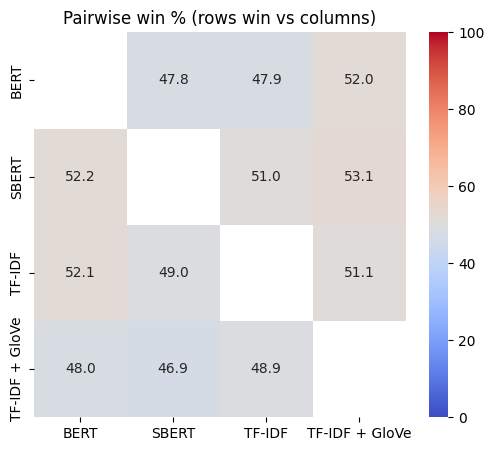

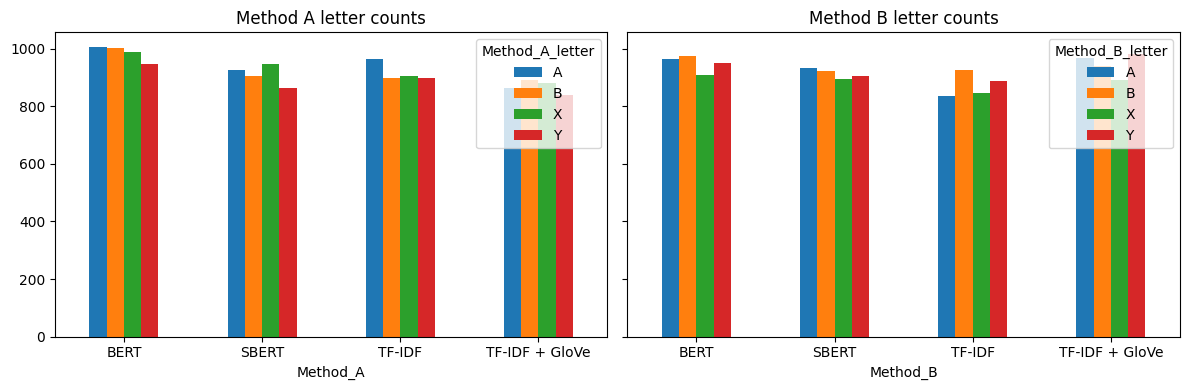

In [21]:
import seaborn as sns
import numpy as np
import itertools
from scipy.stats import chi2_contingency

# Additional analyses & plots you can run quickly (uses existing variables: table, comparisons, counts_A, counts_B)

# 1) Heatmap of score x letter (percentages)
prop_table = table.div(table.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(6,4))
sns.heatmap(prop_table, annot=True, fmt=".1f", cmap="Blues", ax=ax)
ax.set_title("Score distribution by Letter (%)")
plt.show()

# 2) Pairwise chi-square + Cramer's V for Method_A letter distributions
methods = counts_A.index.tolist()
pairs = list(itertools.combinations(methods, 2))
results = []
for a, b in pairs:
    sub = pd.concat([counts_A.loc[a], counts_A.loc[b]], axis=1).T
    chi2, p, dof, _ = chi2_contingency(sub)
    n = sub.values.sum()
    r, k = sub.shape
    cramers_v = np.sqrt(chi2 / (n * min(r-1, k-1)))
    results.append((a, b, p, cramers_v))
res_df = pd.DataFrame(results, columns=["method_a","method_b","p_value","cramers_v"]).sort_values("p_value")
print(res_df)

# 3) Win rates per method (when pairwise compared) and heatmap of pairwise win %.
pairs = comparisons.apply(lambda r: tuple(sorted([r.Method_A, r.Method_B])), axis=1)
comparisons["_pair"] = pairs
pair_groups = comparisons.groupby("_pair")
methods = sorted(comparisons.Method_A.unique())
win_matrix = pd.DataFrame(index=methods, columns=methods, dtype=float).fillna(np.nan)
for pair, group in pair_groups:
    m1, m2 = pair
    wins = group["Winner_Method"].value_counts()
    total = len(group)
    win_matrix.loc[m1, m2] = wins.get(m1, 0) / total * 100
    win_matrix.loc[m2, m1] = wins.get(m2, 0) / total * 100

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(win_matrix, annot=True, fmt=".1f", cmap="coolwarm", vmin=0, vmax=100, ax=ax)
ax.set_title("Pairwise win % (rows win vs columns)")
plt.show()

# 4) Quick summary plots: letter distributions for Method_A vs Method_B side-by-side
fig, axes = plt.subplots(1,2, figsize=(12,4), sharey=True)
counts_A.plot(kind="bar", ax=axes[0], rot=0); axes[0].set_title("Method A letter counts")
counts_B.plot(kind="bar", ax=axes[1], rot=0); axes[1].set_title("Method B letter counts")
plt.tight_layout(); plt.show()

# Looking at actual Scores

In [27]:
scores.head()

,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Scored,Letter,Score
0,struggle,BERT,4,31.49,Psalter,142,"Hear my prayer, O Lord; give ear unto my suppl...",False,A,1
1,struggle,SBERT,4,96.08,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,False,B,0
2,creation,TF-IDF + GloVe,2,13.98,Bible,122,1An ode of ascents Ilift my eyes to You Whodwe...,False,A,2
3,creation,BERT,2,40.51,Psalter,42,"Judge me, God, and give judgment in my cause a...",False,B,1
4,creation,SBERT,2,96.40,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,False,C,3


In [30]:
pd.pivot_table(data=scores, 
               index='Method', 
               values='Score',
               aggfunc=['mean', 'count'])

,mean,count
,Score,Score
Method,,
BERT,1.357381,2994
SBERT,1.293091,2750
TF-IDF,1.091456,2493
TF-IDF + GloVe,1.723881,2546


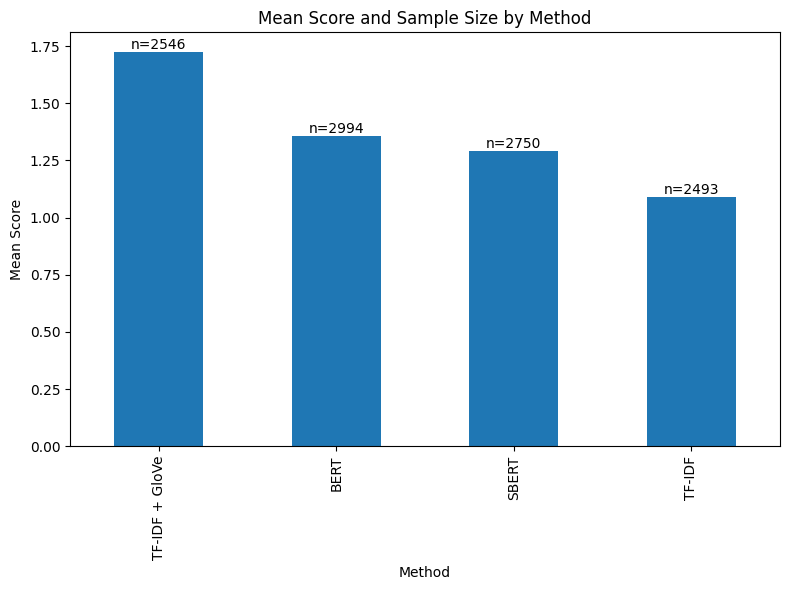

In [32]:
pivot = pd.pivot_table(
    data=scores,
    index="Method",
    values="Score",
    aggfunc=["mean", "count"]
)

pivot.columns = ["Mean Score", "Count"]
pivot = pivot.sort_values("Mean Score", ascending=False)

fig, ax1 = plt.subplots(figsize=(8, 6))

pivot["Mean Score"].plot(
    kind="bar",
    ax=ax1
)

ax1.set_ylabel("Mean Score")
ax1.set_title("Mean Score and Sample Size by Method")

for i, count in enumerate(pivot["Count"]):
    ax1.text(i, pivot["Mean Score"].iloc[i], f"n={count}",
             ha="center", va="bottom")

plt.tight_layout()
plt.show()

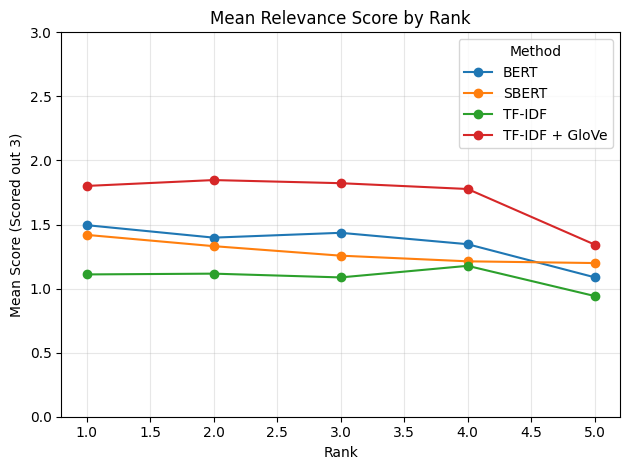

In [39]:
pivoted = pd.pivot_table(
    data=scores,
    index=["Method", "Rank"],
    values="Score",
    aggfunc="mean"
).reset_index()

import matplotlib.pyplot as plt

for method in pivoted["Method"].unique():
    subset = pivoted[pivoted["Method"] == method]

    plt.plot(
        subset["Rank"],
        subset["Score"],
        marker="o",
        label=method
    )
    
plt.ylim(0, 3)

plt.xlabel("Rank")
plt.ylabel("Mean Score (Scored out 3)")
plt.title("Mean Relevance Score by Rank")
plt.legend(title="Method")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Precision@k
Treat scores ≥ 2 as relevant.

In [41]:
scores["Relevant"] = scores["Score"] >= 2

scores.head()

,Query,Method,Rank,Similarity Score (%),Text,Psalm Num,Verse,Scored,Letter,Score,Relevant
0,struggle,BERT,4,31.49,Psalter,142,"Hear my prayer, O Lord; give ear unto my suppl...",False,A,1,False
1,struggle,SBERT,4,96.08,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,False,B,0,False
2,creation,TF-IDF + GloVe,2,13.98,Bible,122,1An ode of ascents Ilift my eyes to You Whodwe...,False,A,2,True
3,creation,BERT,2,40.51,Psalter,42,"Judge me, God, and give judgment in my cause a...",False,B,1,False
4,creation,SBERT,2,96.40,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,False,C,3,True


* What proportion of retrieved passages are relevant?
* Which method retrieves useful results most consistently?

In [42]:
scores.groupby("Method")["Relevant"].mean()

Method
BERT              0.415832
SBERT             0.425455
TF-IDF            0.396711
TF-IDF + GloVe    0.546740
Name: Relevant, dtype: float64

* **TF-IDF + GloVe** achieved the highest relevance rate (**54.7%**), indicating that it returned relevant passages more frequently than the other retrieval methods.
* **SBERT** ranked second with a relevance rate of **42.5%**, followed closely by **BERT** at **41.6%**.
* **TF-IDF** produced the lowest relevance rate (**39.7%**), suggesting that it was less effective at retrieving relevant passages overall.
* The improvement of **TF-IDF + GloVe** over standard **TF-IDF** suggests that incorporating semantic word embeddings helped identify relevant passages that keyword matching alone may have missed.
* While **BERT** and **SBERT** outperformed traditional TF-IDF, their relevance rates remained substantially below that of **TF-IDF + GloVe** in this evaluation.
* Overall, these results suggest that **TF-IDF + GloVe was the most effective retrieval approach** among the methods tested when relevance is defined as a score of 2 or higher.
